# Netflix Data Analysis: Trends & Insights

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('netflix_titles.csv')

## Dataset Overview

We read the data

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [5]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


## Data Cleaning

In [6]:
df["director"].fillna("Unknown" , inplace=True)
df["cast"].fillna("Unknown" , inplace=True)
df["country"].fillna("Unknown" , inplace=True)

In [7]:
df.dropna(subset=["date_added" , "rating" , "duration"] , inplace=True)

In [8]:
df["date_added"] = pd.to_datetime(df["date_added"], format="mixed", errors="coerce")

These steps ensure consistency in the dataset and enable accurate time-based analysis.

## Exploratory Data Analysis (EDA)

### Movies vs TV Shows Over Time (Based on Year Added)

In [9]:
df["added_year"] = df["date_added"].dt.year

In [10]:
df_grouped = df.groupby(["added_year", "type"]).size().unstack()
df_grouped = df_grouped.fillna(0)
df_grouped

type,Movie,TV Show
added_year,,
2008,1.0,1.0
2009,2.0,0.0
2010,1.0,0.0
2011,13.0,0.0
2012,3.0,0.0
2013,6.0,5.0
2014,19.0,5.0
2015,56.0,26.0
2016,251.0,175.0


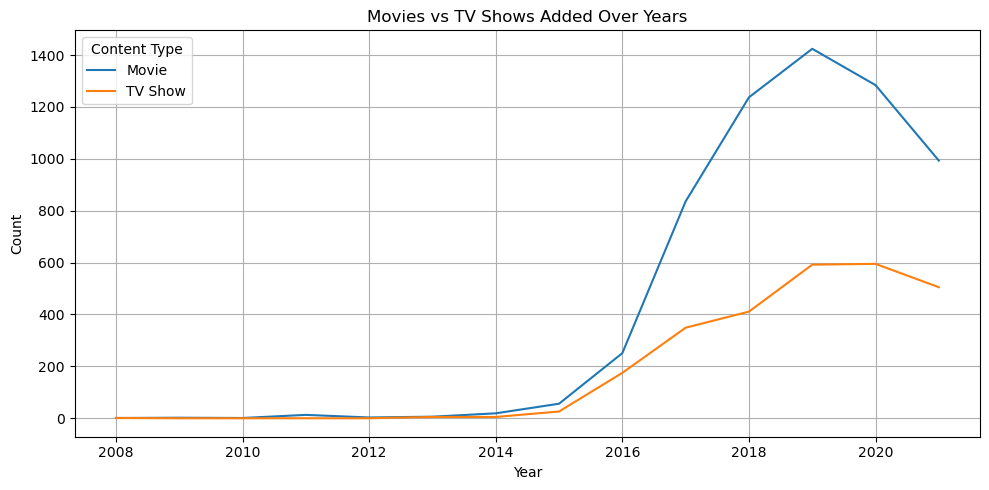

In [11]:
df_grouped.plot(kind="line", figsize=(10,5))
plt.title("Movies vs TV Shows Added Over Years")
plt.xlabel("Year")
plt.ylabel("Count")
plt.legend(title="Content Type")
plt.grid(True)
plt.tight_layout()
plt.show()

- Netflix saw rapid growth in content after 2015, with movie additions jumping significantly, indicating aggressive platform expansion.
- Over time, TV Shows increased steadily, showing a shift toward series-based content, though movies still remain dominant.

### Top Countries by Content on Netflix

In [12]:
df_country = df.copy()
df_country["country"] = df_country["country"].str.split(r",\s*")
df_country = df_country.explode("country")
df_country = df_country[df_country["country"] != "Unknown"]

In [13]:
top_countries = df_country["country"].value_counts().head(10)
top_countries

country
United States     3681
India             1046
United Kingdom     805
Canada             445
France             393
Japan              316
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64

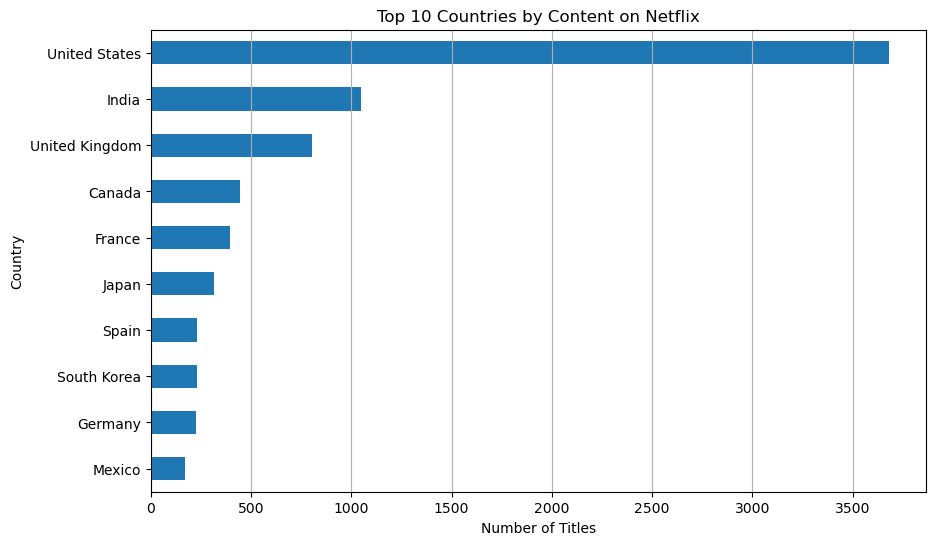

In [14]:
top_countries.sort_values().plot(kind="barh", figsize=(10,6))
plt.title("Top 10 Countries by Content on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.grid(axis='x')
plt.show()

- The United States dominates Netflix content production by a massive margin, contributing more than 3× the content of the next country, highlighting its central role in the platform’s catalog.
- Content is heavily concentrated in a few countries like India, the United Kingdom, and Canada, indicating that Netflix relies on key regional markets rather than evenly distributed global production

### Overall Distribution of Content Ratings

In [15]:
df["rating"].value_counts()

rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

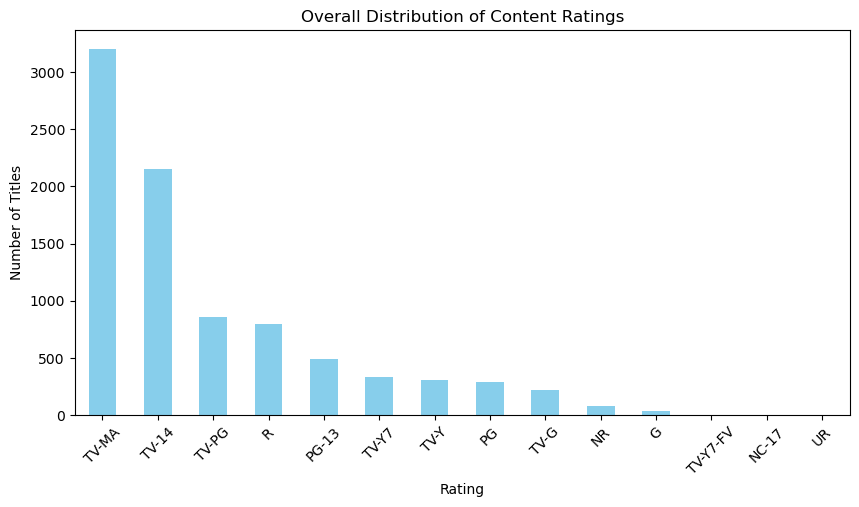

In [16]:
df["rating"].value_counts().plot(kind="bar", figsize=(10,5) , color="skyblue")
plt.title("Overall Distribution of Content Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()

Netflix content is dominated by mature ratings like TV-MA( Television - Mature Audience ).

### Rating Distribution by Content Type

In [17]:
pivot = pd.crosstab(df["rating"], df["type"])
pivot

type,Movie,TV Show
rating,,
G,41,0
NC-17,3,0
NR,75,4
PG,287,0
PG-13,490,0
R,797,2
TV-14,1427,730
TV-G,126,94
TV-MA,2062,1143


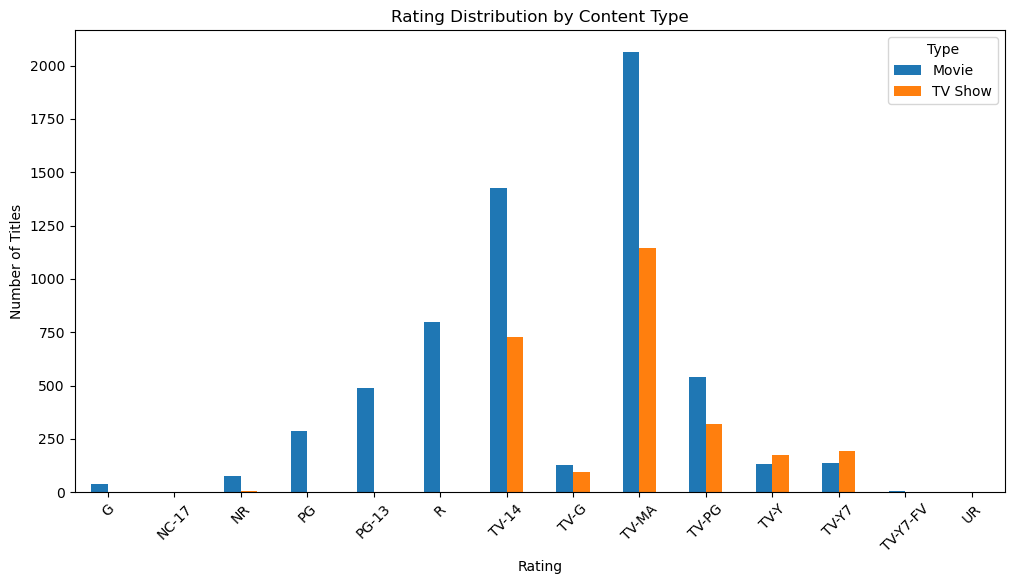

In [18]:
pivot.plot(kind="bar", figsize=(12,6))
plt.title("Rating Distribution by Content Type")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.legend(title="Type")

plt.show()

Both Movies and TV Shows are dominated by mature ratings, with TV Shows showing a relatively higher concentration in adult categories, indicating targeted audience segmentation.

In [19]:
df_genre = df.copy()

df_genre["listed_in"] = df_genre["listed_in"].str.split(", ")
df_genre = df_genre.explode("listed_in")

In [20]:
top_genres = df_genre["listed_in"].value_counts().head(10)
top_genres

listed_in
International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1349
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

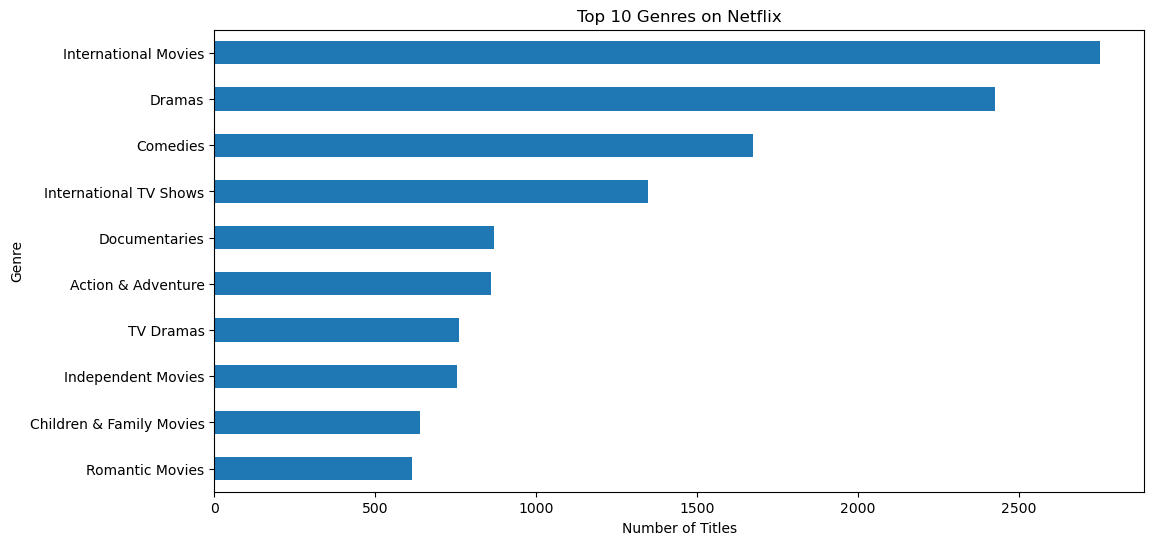

In [21]:
top_genres.sort_values().plot(kind="barh", figsize=(12,6))
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.show()

Netflix has a lot of international and drama content, along with a mix of popular and niche genres to meet different audience preferences.

## Key Insights

- Netflix content grew rapidly after 2015, showing major platform expansion.
- Movies dominate overall, but TV Shows increased significantly over time.
- The United States leads content production, followed by India and the UK.
- Mature ratings (like TV-MA) are most common, indicating adult-focused content.
- International and drama genres are the most prominent.

## Conclusion

Netflix has expanded rapidly after 2015 with a strong focus on movies and growing investment in TV Shows. 
Its content is concentrated in key countries and leans toward mature audiences, while maintaining a diverse mix of genres.